<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/statistics/worldOilandGasProduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World oil and gas production: statistics connected to NeqSim

**Audience.** Energy and process engineers, students, analysts, and decision
makers who want to connect public production statistics to thermodynamic and
process consequences.

**Prerequisites.** Basic Python, mole fractions, energy units, and steady-state
process concepts. All calculations use SI-derived units; `bara` and `Sm³` are
stated explicitly where they are industry conventions.

**Learning objectives**

1. audit a compact, reproducible 2024 production snapshot;
2. compare producer shares and concentration without confusing production with
   reserves, demand, or emissions;
3. use NeqSim SRK and ISO 6976 functionality for a representative export gas;
4. connect energy statistics to standard volume, compression, and combustion;
5. quantify composition and export-pressure sensitivities; and
6. reuse a validated workflow for another public dataset.

This notebook is a screening study. It does not forecast production or allocate
emissions to countries, companies, fields, or consumers.

## 1. Reproducible environment

The setup cell installs the current public PyPI release only when NeqSim is
missing. Google Colab can therefore run the notebook from a clean runtime
without local files, private data, credentials, or a runtime restart.

In [2]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

In [3]:
import json
import platform
import subprocess
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim
from neqsim.standards import ISO6976


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "grey": "#555555",
}

runtime = {
    "NeqSim": version("neqsim"),
    "Python": platform.python_version(),
    "Java": subprocess.run(
        ["java", "-version"],
        capture_output=True,
        check=True,
        text=True,
    ).stderr.splitlines()[0],
}
display(pd.DataFrame(runtime.items(), columns=["Runtime", "Version"]))

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"


## 2. Data boundary and provenance

The embedded snapshot uses 2024 production energy from the Energy Institute
Statistical Review of World Energy 2025, redistributed by Our World in Data
under CC BY. The values were retrieved on 26 July 2026 and rounded to the
nearest 10 TWh, except Norway. The Energy Institute reports that historical
series may be revised between editions.

Oil and gas are both expressed in TWh of primary energy so their magnitudes are
comparable. This is not electrical output. The country lists are deliberately
compact; `Other producers` closes each list to the published world total.

In [4]:
production_2024 = {
    "Oil": {
        "World": 52_830.0,
        "United States": 9_980.0,
        "Russia": 6_120.0,
        "Saudi Arabia": 5_930.0,
        "Canada": 3_370.0,
        "Iran": 2_730.0,
        "Iraq": 2_510.0,
        "China": 2_480.0,
        "Brazil": 2_120.0,
        "United Arab Emirates": 2_090.0,
        "Kuwait": 1_520.0,
        "Norway": 999.0,
    },
    "Natural gas": {
        "World": 41_240.0,
        "United States": 10_330.0,
        "Russia": 6_300.0,
        "Iran": 2_630.0,
        "China": 2_480.0,
        "Canada": 1_940.0,
        "Qatar": 1_790.0,
    },
}

rows = []
for product, values in production_2024.items():
    world_total = values["World"]
    listed_total = sum(
        value
        for country, value in values.items()
        if country != "World"
    )
    for country, value in values.items():
        if country != "World":
            rows.append(
                {
                    "Product": product,
                    "Producer": country,
                    "Production [TWh]": value,
                }
            )
    rows.append(
        {
            "Product": product,
            "Producer": "Other producers",
            "Production [TWh]": world_total - listed_total,
        }
    )

production_table = pd.DataFrame(rows)
display(production_table)

,Product,Producer,Production [TWh]
0,Oil,United States,9980.0
1,Oil,Russia,6120.0
2,Oil,Saudi Arabia,5930.0
3,Oil,Canada,3370.0
4,Oil,Iran,2730.0
5,Oil,Iraq,2510.0
6,Oil,China,2480.0
7,Oil,Brazil,2120.0
8,Oil,United Arab Emirates,2090.0
9,Oil,Kuwait,1520.0


## 3. Statistical checks

Producer share is calculated on a common energy basis:

$$
s_i = \frac{E_i}{E_{\mathrm{world}}}
$$

Here $E_i$ is annual production by producer $i$ in TWh and
$E_{\mathrm{world}}$ is the matching world total in TWh.

In [5]:
world_totals = {
    product: values["World"]
    for product, values in production_2024.items()
}
production_table["World share [%]"] = production_table.apply(
    lambda row: (
        100.0
        * row["Production [TWh]"]
        / world_totals[row["Product"]]
    ),
    axis=1,
)

closure_table = (
    production_table.groupby("Product")["Production [TWh]"]
    .sum()
    .rename("Reconstructed world [TWh]")
    .to_frame()
)
closure_table["Published world [TWh]"] = pd.Series(world_totals)
closure_table["Residual [TWh]"] = (
    closure_table["Reconstructed world [TWh]"]
    - closure_table["Published world [TWh]"]
)
display(closure_table)

,Reconstructed world [TWh],Published world [TWh],Residual [TWh]
Product,,,
Natural gas,41240.0,41240.0,0.0
Oil,52830.0,52830.0,0.0


## 4. Production landscape

The first figure separates named producers from the closing `Other producers`
category. The common TWh basis supports comparison, but oil and gas conversion
chains, market values, and environmental effects remain different.

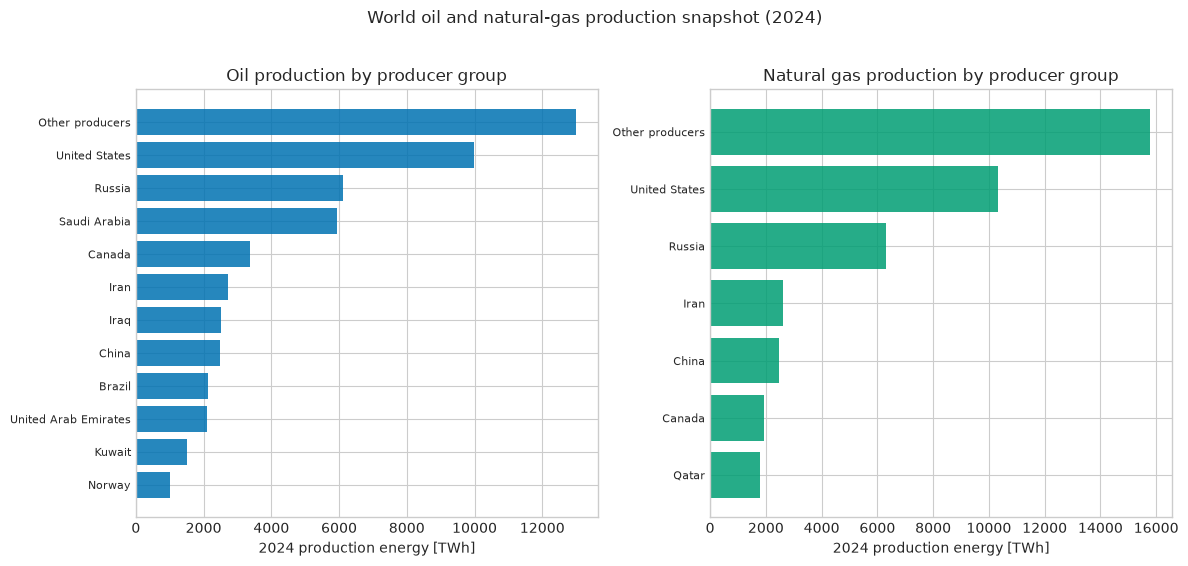

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for axis, product, color in zip(
    axes,
    ["Oil", "Natural gas"],
    [COLORS["blue"], COLORS["green"]],
):
    subset = (
        production_table[production_table["Product"] == product]
        .sort_values("Production [TWh]")
    )
    axis.barh(
        subset["Producer"],
        subset["Production [TWh]"],
        color=color,
        alpha=0.85,
    )
    axis.set_xlabel("2024 production energy [TWh]")
    axis.set_title(f"{product} production by producer group")
    axis.tick_params(axis="y", labelsize=8)

figure.suptitle(
    "World oil and natural-gas production snapshot (2024)",
    y=1.02,
)
figure.tight_layout()
plt.show()

The United States is the largest named producer in both panels. The visual also
prevents a common mistake: a top-producer ranking does not imply that named
producers cover the entire world total.

A simple concentration indicator is the Herfindahl-Hirschman index:

$$
H = \sum_i s_i^2
$$

The index depends on aggregation. Treating all unlisted countries as one
`Other producers` group overstates true country-level concentration, so the
result is reported as a grouped-screening indicator.

In [7]:
concentration_rows = []
for product, group in production_table.groupby("Product"):
    shares = group["World share [%]"] / 100.0
    concentration_rows.append(
        {
            "Product": product,
            "Grouped HHI [-]": float(np.square(shares).sum()),
            "Largest named share [%]": float(
                group.loc[
                    group["Producer"] != "Other producers",
                    "World share [%]",
                ].max()
            ),
            "Named producers represented [-]": int(
                (group["Producer"] != "Other producers").sum()
            ),
        }
    )

concentration_table = pd.DataFrame(concentration_rows)
display(concentration_table.round(4))

,Product,Grouped HHI [-],Largest named share [%],Named producers represented [-]
0,Natural gas,0.2441,25.0485,6
1,Oil,0.1376,18.8908,11


## 5. How NeqSim represents the gas

Statistics provide energy, not composition or process state. NeqSim requires a
fluid model, components, temperature, pressure, and flow. We use SRK because it
is a standard cubic equation of state for hydrocarbon-gas screening. A
`ThermodynamicOperations` TP flash solves the equilibrium state.

The composition below is a documented synthetic export gas, not a world
average. Mole fractions sum to one. Standard volume uses 15°C and 1.01325 bara.

In [8]:
gas_composition = {
    "nitrogen": 0.010,
    "CO2": 0.010,
    "methane": 0.900,
    "ethane": 0.055,
    "propane": 0.015,
    "i-butane": 0.005,
    "n-butane": 0.005,
}

ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)


def make_gas(composition, temperature_k=288.15, pressure_bara=1.01325):
    fluid = jneqsim.thermo.system.SystemSrkEos(
        temperature_k,
        pressure_bara,
    )
    for component, mole_fraction in composition.items():
        fluid.addComponent(component, mole_fraction)
    fluid.setMixingRule("classic")
    fluid.init(0)
    ThermodynamicOperations(fluid).TPflash()
    fluid.initProperties()
    return fluid


standard_gas = make_gas(gas_composition)
fluid_summary = pd.DataFrame(
    {
        "Quantity": [
            "Composition sum",
            "Phases",
            "Molar mass",
            "Density at 15°C and 1.01325 bara",
        ],
        "Value": [
            sum(gas_composition.values()),
            standard_gas.getNumberOfPhases(),
            standard_gas.getMolarMass() * 1000.0,
            standard_gas.getDensity("kg/m3"),
        ],
        "Unit": ["mol/mol", "-", "kg/kmol", "kg/Sm³"],
    }
)
display(fluid_summary.round(6))

,Quantity,Value,Unit
0,Composition sum,1.000000,mol/mol
1,Phases,1.000000,-
2,Molar mass,18.055470,kg/kmol
3,Density at 15°C and 1.01325 bara,0.765528,kg/Sm³


## 6. ISO 6976 energy quality

NeqSim's `ISO6976` wrapper calculates gross and net calorific value, relative
density, and Wobbe index from the same fluid object. The Wobbe relation is

$$
W_s = \frac{H_s}{\sqrt{d_r}}
$$

where $W_s$ is superior Wobbe index in MJ/Sm³, $H_s$ is gross calorific value
in MJ/Sm³, and $d_r$ is relative density.

In [9]:
def iso6976_quality(fluid):
    standard = ISO6976(fluid)
    standard.setReferenceType("volume")
    standard.setVolRefT(15.0)
    standard.setEnergyRefT(25.0)
    standard.calculate()
    return {
        "Gross CV [MJ/Sm³]": (
            standard.getValue("SuperiorCalorificValue") / 1000.0
        ),
        "Net CV [MJ/Sm³]": (
            standard.getValue("InferiorCalorificValue") / 1000.0
        ),
        "Wobbe [MJ/Sm³]": (
            standard.getValue("SuperiorWobbeIndex") / 1000.0
        ),
        "Relative density [-]": standard.getValue(
            "RelativeDensity"
        ),
    }


base_quality = iso6976_quality(standard_gas)
display(
    pd.DataFrame(
        base_quality.items(),
        columns=["Quantity", "Value"],
    ).round(6)
)

,Quantity,Value
0,Gross CV [MJ/Sm³],40.254052
1,Net CV [MJ/Sm³],36.381731
2,Wobbe [MJ/Sm³],50.932126
3,Relative density [-],0.624648


## 7. Energy-to-volume bridge

For a stated gas quality, annual standard volume follows from net energy:

$$
V_s = \frac{E}{H_i}
$$

Here $V_s$ is standard volume in Sm³, $E$ is energy in MJ, and $H_i$ is net
calorific value in MJ/Sm³. The Energy Institute independently reports global
2024 gas production of 4,124 bcm. Agreement is expected only within a screening
tolerance because world production contains many gas qualities and the TWh
series uses source-specific energy conventions.

In [10]:
TWH_TO_MJ = 3.6e9
SM3_PER_BCM = 1.0e9
EI_WORLD_GAS_BCM_2024 = 4_124.0

world_gas_energy_mj = (
    production_2024["Natural gas"]["World"] * TWH_TO_MJ
)
energy_derived_world_gas_bcm = (
    world_gas_energy_mj
    / base_quality["Net CV [MJ/Sm³]"]
    / SM3_PER_BCM
)
volume_relative_difference = (
    energy_derived_world_gas_bcm - EI_WORLD_GAS_BCM_2024
) / EI_WORLD_GAS_BCM_2024

volume_bridge = pd.DataFrame(
    {
        "Quantity": [
            "World gas production energy",
            "NeqSim energy-derived standard volume",
            "Energy Institute reported volume",
            "Relative difference",
        ],
        "Value": [
            production_2024["Natural gas"]["World"],
            energy_derived_world_gas_bcm,
            EI_WORLD_GAS_BCM_2024,
            100.0 * volume_relative_difference,
        ],
        "Unit": ["TWh", "bcm", "bcm", "%"],
    }
)
display(volume_bridge.round(3))

,Quantity,Value,Unit
0,World gas production energy,41240.000,TWh
1,NeqSim energy-derived standard volume,4080.729,bcm
2,Energy Institute reported volume,4124.000,bcm
3,Relative difference,-1.049,%


## 8. Composition scenarios

Production volume alone cannot determine interchangeability. Four synthetic
scenarios replace methane while keeping the total mole fraction equal to one.
They show how the same nominal standard volume can carry different energy and
Wobbe index.

In [11]:
composition_scenarios = {
    "Base export gas": gas_composition,
    "Lean gas": {
        **gas_composition,
        "methane": 0.945,
        "ethane": 0.020,
        "propane": 0.005,
    },
    "CO2-rich gas": {
        **gas_composition,
        "methane": 0.860,
        "CO2": 0.050,
    },
    "Nitrogen-rich gas": {
        **gas_composition,
        "methane": 0.860,
        "nitrogen": 0.050,
    },
}

quality_rows = []
for scenario, composition in composition_scenarios.items():
    normalized = {
        component: fraction / sum(composition.values())
        for component, fraction in composition.items()
    }
    scenario_gas = make_gas(normalized)
    quality_rows.append(
        {
            "Scenario": scenario,
            **iso6976_quality(scenario_gas),
        }
    )

quality_table = pd.DataFrame(quality_rows)
display(quality_table.round(4))

,Scenario,Gross CV [MJ/Sm³],Net CV [MJ/Sm³],Wobbe [MJ/Sm³],Relative density [-]
0,Base export gas,40.2541,36.3817,50.9321,0.6246
1,Lean gas,38.6868,34.9180,50.0359,0.5978
2,CO2-rich gas,38.7483,35.0249,47.5724,0.6634
3,Nitrogen-rich gas,38.7394,35.0168,48.3810,0.6411


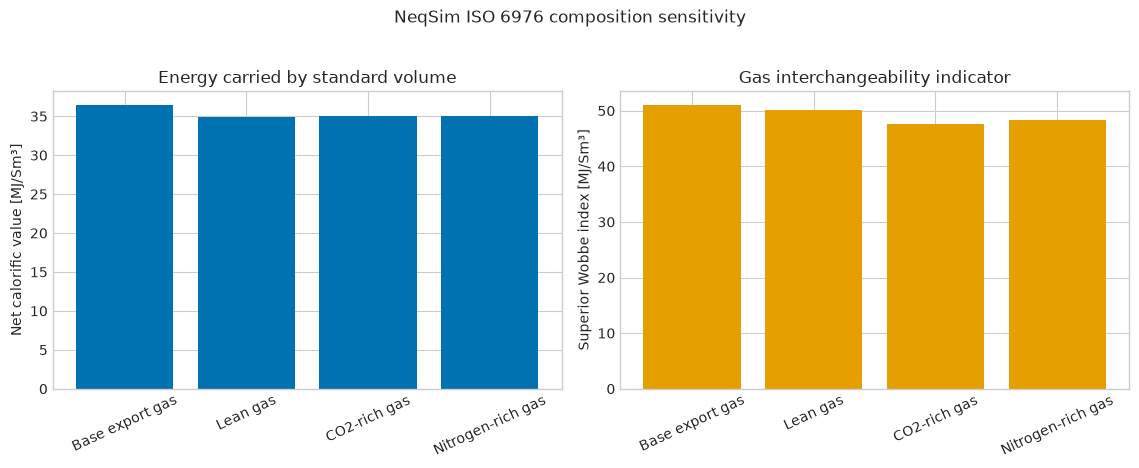

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

axes[0].bar(
    quality_table["Scenario"],
    quality_table["Net CV [MJ/Sm³]"],
    color=COLORS["blue"],
)
axes[0].set_ylabel("Net calorific value [MJ/Sm³]")
axes[0].set_title("Energy carried by standard volume")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(
    quality_table["Scenario"],
    quality_table["Wobbe [MJ/Sm³]"],
    color=COLORS["orange"],
)
axes[1].set_ylabel("Superior Wobbe index [MJ/Sm³]")
axes[1].set_title("Gas interchangeability indicator")
axes[1].tick_params(axis="x", rotation=25)

figure.suptitle("NeqSim ISO 6976 composition sensitivity", y=1.03)
figure.tight_layout()
plt.show()

Inert enrichment lowers calorific value and Wobbe index. The result explains why
a bcm statistic is incomplete for process design: composition affects sales
energy, combustion equipment, density, and compression.

## 9. Representative export-compression workflow

A substantial NeqSim application now connects the statistical context to real
process classes. `Stream` supplies a 60-bara inlet boundary, `Compressor`
applies outlet pressure and isentropic efficiency, and `ProcessSystem` executes
the connected objects. The 20 million Sm³/d train is illustrative, not a
particular facility.

The adiabatic compressor satisfies a steady-flow energy relation:

$$
\dot W = \dot m(h_2-h_1)
$$

Power $\dot W$ is in kW when mass flow $\dot m$ and NeqSim enthalpies use
consistent units.

In [13]:
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

REPRESENTATIVE_FLOW_SM3_DAY = 20.0e6
STANDARD_HOURS_PER_DAY = 24.0
standard_density_kg_sm3 = standard_gas.getDensity("kg/m3")
representative_mass_flow_kg_h = (
    REPRESENTATIVE_FLOW_SM3_DAY
    * standard_density_kg_sm3
    / STANDARD_HOURS_PER_DAY
)


def run_export_compressor(outlet_pressure_bara):
    inlet_fluid = make_gas(
        gas_composition,
        temperature_k=303.15,
        pressure_bara=60.0,
    )
    inlet_stream = Stream("Export compressor inlet", inlet_fluid)
    inlet_stream.setFlowRate(
        representative_mass_flow_kg_h,
        "kg/hr",
    )
    inlet_stream.setTemperature(30.0, "C")
    inlet_stream.setPressure(60.0, "bara")

    compressor = Compressor("Export compressor", inlet_stream)
    compressor.setOutletPressure(outlet_pressure_bara, "bara")
    compressor.setIsentropicEfficiency(0.78)

    process = ProcessSystem()
    process.add(inlet_stream)
    process.add(compressor)
    process.run()

    return {
        "Outlet pressure [bara]": outlet_pressure_bara,
        "Power [MW]": compressor.getPower("kW") / 1000.0,
        "Outlet temperature [°C]": (
            compressor.getOutletStream().getTemperature("C")
        ),
    }


compressor_table = pd.DataFrame(
    [
        run_export_compressor(outlet_pressure)
        for outlet_pressure in [90.0, 120.0, 150.0, 180.0]
    ]
)
display(compressor_table.round(3))

,Outlet pressure [bara],Power [MW],Outlet temperature [°C]
0,90.0,12.096,66.383
1,120.0,21.584,93.199
2,150.0,29.557,114.500
3,180.0,36.528,132.199


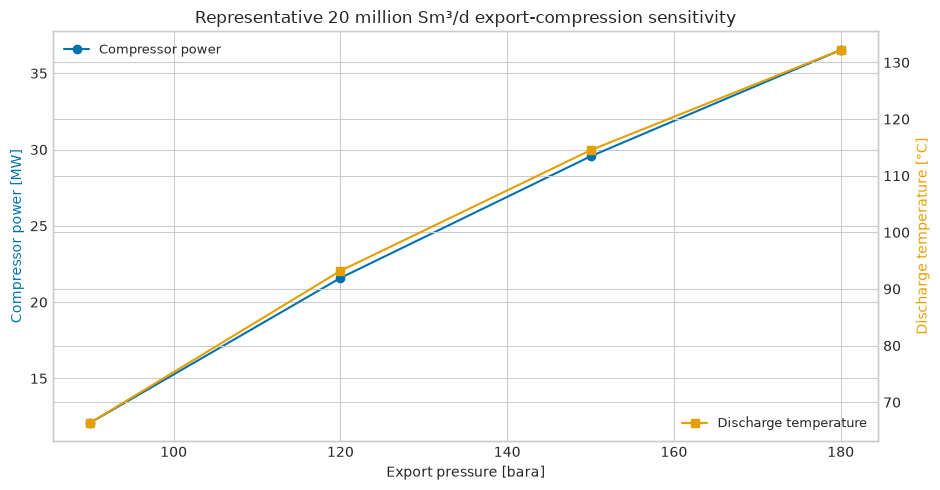

In [14]:
figure, primary_axis = plt.subplots(figsize=(9.5, 5.0))
secondary_axis = primary_axis.twinx()

primary_axis.plot(
    compressor_table["Outlet pressure [bara]"],
    compressor_table["Power [MW]"],
    color=COLORS["blue"],
    marker="o",
    label="Compressor power",
)
secondary_axis.plot(
    compressor_table["Outlet pressure [bara]"],
    compressor_table["Outlet temperature [°C]"],
    color=COLORS["orange"],
    marker="s",
    label="Discharge temperature",
)

primary_axis.set_xlabel("Export pressure [bara]")
primary_axis.set_ylabel("Compressor power [MW]", color=COLORS["blue"])
secondary_axis.set_ylabel(
    "Discharge temperature [°C]",
    color=COLORS["orange"],
)
primary_axis.set_title(
    "Representative 20 million Sm³/d export-compression sensitivity"
)
primary_axis.legend(loc="upper left")
secondary_axis.legend(loc="lower right")
figure.tight_layout()
plt.show()

Both power and discharge temperature increase with pressure ratio. A project
model would add stages, intercooling, compressor maps, anti-surge control,
mechanical limits, and off-design efficiencies before equipment selection.

## 10. Direct-combustion scenario

A production statistic is not an emissions inventory. For teaching only, the
next section assumes all produced gas is completely combusted. The carbon
factor comes from the NeqSim component inventory:

$$
I_{\mathrm{CO_2}} =
\frac{n_C M_{\mathrm{CO_2}}}{H_i M_{\mathrm{fuel}}}
$$

$I_{\mathrm{CO_2}}$ is kg CO₂/GJ LHV, $n_C$ is carbon atoms per mole of
mixture, $M_{\mathrm{CO_2}}$ is kg/kmol, $H_i$ is MJ/kg, and
$M_{\mathrm{fuel}}$ is kg/kmol.

In [15]:
mass_standard = ISO6976(standard_gas)
mass_standard.setReferenceType("mass")
mass_standard.setVolRefT(15.0)
mass_standard.setEnergyRefT(25.0)
mass_standard.calculate()
net_energy_mj_kg = (
    mass_standard.getValue("InferiorCalorificValue") / 1000.0
)

carbon_kmol_per_kmol = 0.0
fuel_co2_kmol_per_kmol = 0.0
for component_index in range(standard_gas.getNumberOfComponents()):
    component = standard_gas.getComponent(component_index)
    mole_fraction = float(component.getz())
    component_name = str(component.getName())
    if component.isHydrocarbon():
        carbon_kmol_per_kmol += (
            mole_fraction
            * component.getElements().getNumberOfElements("C")
        )
    elif component_name == "CO2":
        fuel_co2_kmol_per_kmol += mole_fraction

CO2_MOLAR_MASS_KG_KMOL = 44.0095
fuel_molar_mass_kg_kmol = (
    standard_gas.getMolarMass() * 1000.0
)
co2_kg_kg_fuel = (
    (carbon_kmol_per_kmol + fuel_co2_kmol_per_kmol)
    * CO2_MOLAR_MASS_KG_KMOL
    / fuel_molar_mass_kg_kmol
)
co2_kg_gj_lhv = (
    co2_kg_kg_fuel / net_energy_mj_kg * 1000.0
)

carbon_summary = pd.DataFrame(
    {
        "Quantity": [
            "Net calorific value",
            "Direct CO2 per fuel mass",
            "Direct CO2 intensity",
        ],
        "Value": [
            net_energy_mj_kg,
            co2_kg_kg_fuel,
            co2_kg_gj_lhv,
        ],
        "Unit": ["MJ/kg", "kg CO2/kg fuel", "kg CO2/GJ LHV"],
    }
)
display(carbon_summary.round(4))

,Quantity,Value,Unit
0,Net calorific value,47.5252,MJ/kg
1,Direct CO2 per fuel mass,2.6934,kg CO2/kg fuel
2,Direct CO2 intensity,56.6730,kg CO2/GJ LHV


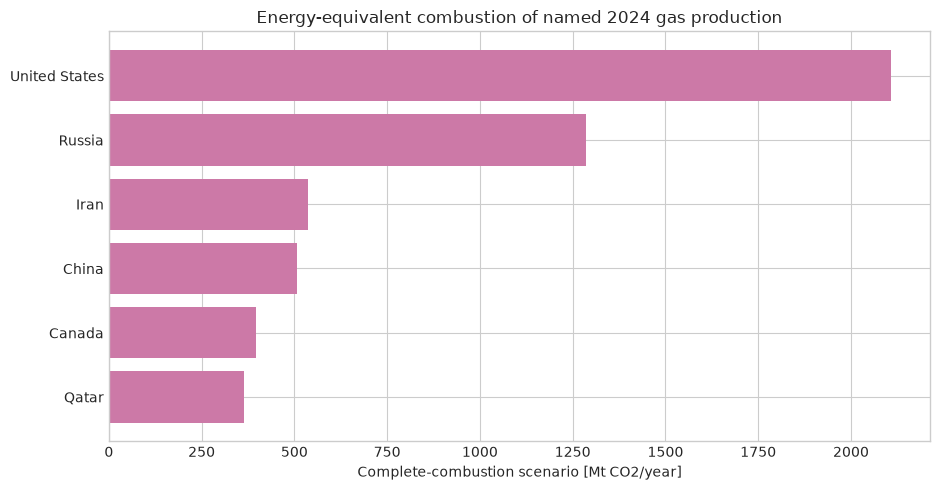

In [16]:
named_gas = production_table[
    (production_table["Product"] == "Natural gas")
    & (production_table["Producer"] != "Other producers")
].copy()
named_gas["Full-combustion scenario [Mt CO2]"] = (
    named_gas["Production [TWh]"]
    * 3.6e6
    * co2_kg_gj_lhv
    / 1.0e9
)

figure, axis = plt.subplots(figsize=(9.5, 5.0))
ordered = named_gas.sort_values(
    "Full-combustion scenario [Mt CO2]"
)
axis.barh(
    ordered["Producer"],
    ordered["Full-combustion scenario [Mt CO2]"],
    color=COLORS["purple"],
)
axis.set_xlabel("Complete-combustion scenario [Mt CO2/year]")
axis.set_title(
    "Energy-equivalent combustion of named 2024 gas production"
)
figure.tight_layout()
plt.show()

The bars are an energy-equivalent scenario, not territorial, lifecycle, or
consumption-based emissions. Reinjection, flaring, methane leakage, LNG,
petrochemical feedstock, trade, carbon capture, and non-energy use are outside
the boundary.

## 11. Verification

Assertions check data closure, fluid definition, phase state, ISO 6976
identities, the independent volume benchmark, process trends, and physically
plausible ranges. They are acceptance criteria for this teaching case, not a
substitute for uncertainty analysis.

In [17]:
wobbe_identity = (
    base_quality["Gross CV [MJ/Sm³]"]
    / np.sqrt(base_quality["Relative density [-]"])
)

validation_checks = {
    "oil data close to world total": abs(
        closure_table.loc["Oil", "Residual [TWh]"]
    ) < 1.0e-9,
    "gas data close to world total": abs(
        closure_table.loc["Natural gas", "Residual [TWh]"]
    ) < 1.0e-9,
    "all production values are positive": (
        production_table["Production [TWh]"] > 0.0
    ).all(),
    "all shares are bounded": (
        production_table["World share [%]"].between(0.0, 100.0)
    ).all(),
    "gas composition closes": abs(
        sum(gas_composition.values()) - 1.0
    ) < 1.0e-12,
    "standard gas is single phase": (
        standard_gas.getNumberOfPhases() == 1
    ),
    "standard density is plausible": (
        0.6 < standard_density_kg_sm3 < 1.0
    ),
    "gross CV exceeds net CV": (
        base_quality["Gross CV [MJ/Sm³]"]
        > base_quality["Net CV [MJ/Sm³]"]
    ),
    "Wobbe identity closes": abs(
        wobbe_identity - base_quality["Wobbe [MJ/Sm³]"]
    ) < 1.0e-10,
    "volumetric LHV is plausible": (
        30.0 < base_quality["Net CV [MJ/Sm³]"] < 45.0
    ),
    "world gas volume benchmark is within ten percent": (
        abs(volume_relative_difference) < 0.10
    ),
    "compressor power is positive": (
        compressor_table["Power [MW]"] > 0.0
    ).all(),
    "power increases with export pressure": (
        compressor_table["Power [MW]"].diff().dropna() > 0.0
    ).all(),
    "temperature increases with export pressure": (
        compressor_table["Outlet temperature [°C]"]
        .diff()
        .dropna()
        > 0.0
    ).all(),
    "carbon intensity is plausible": 45.0 < co2_kg_gj_lhv < 65.0,
    "all numerical tables are finite": all(
        np.isfinite(frame.select_dtypes("number")).all().all()
        for frame in [
            production_table,
            concentration_table,
            quality_table,
            compressor_table,
            named_gas,
        ]
    ),
}

validation_table = pd.DataFrame(
    {
        "Check": list(validation_checks),
        "Passed": list(validation_checks.values()),
    }
)
display(validation_table)
assert all(validation_checks.values())
print(f"All {len(validation_checks)} engineering checks passed.")

All 16 engineering checks passed.


,Check,Passed
0,oil data close to world total,True
1,gas data close to world total,True
2,all production values are positive,True
3,all shares are bounded,True
4,gas composition closes,True
5,standard gas is single phase,True
6,standard density is plausible,True
7,gross CV exceeds net CV,True
8,Wobbe identity closes,True
9,volumetric LHV is plausible,True


In [18]:
reusable_summary = {
    "data_year": 2024,
    "world_oil_production_twh": production_2024["Oil"]["World"],
    "world_gas_production_twh": (
        production_2024["Natural gas"]["World"]
    ),
    "energy_derived_world_gas_bcm": round(
        energy_derived_world_gas_bcm,
        3,
    ),
    "net_calorific_value_mj_sm3": round(
        base_quality["Net CV [MJ/Sm³]"],
        4,
    ),
    "wobbe_index_mj_sm3": round(
        base_quality["Wobbe [MJ/Sm³]"],
        4,
    ),
    "direct_co2_kg_gj_lhv": round(co2_kg_gj_lhv, 4),
    "engineering_checks_passed": int(
        sum(validation_checks.values())
    ),
}
print(json.dumps(reusable_summary, indent=2))

{
  "data_year": 2024,
  "world_oil_production_twh": 52830.0,
  "world_gas_production_twh": 41240.0,
  "energy_derived_world_gas_bcm": 4080.729,
  "net_calorific_value_mj_sm3": 36.3817,
  "wobbe_index_mj_sm3": 50.9321,
  "direct_co2_kg_gj_lhv": 56.673,
  "engineering_checks_passed": 16
}


## 12. Conclusions and practical limitations

- Public statistics close exactly to the stated world totals after adding the
  explicit `Other producers` category.
- NeqSim turns an energy-only statistic into a transparent gas-quality,
  standard-volume, compression, and direct-combustion workflow.
- Composition is essential: standard volume alone does not define energy or
  interchangeability.
- Export pressure materially changes power and discharge temperature.
- The embedded country snapshot is rounded and may be revised; rerun the audit
  when replacing it with a newer Energy Institute or EIA release.

Do not use the screening compressor for machinery selection, and do not call the
combustion scenario an emissions inventory.

## 13. Troubleshooting

- **NeqSim import fails:** rerun the setup cell in a clean Colab runtime.
- **ISO 6976 fails:** verify component names, normalize mole fractions, flash the
  fluid, and confirm a gas phase exists.
- **Volume comparison changes:** check whether the source reports gross or net
  energy and whether standard conditions differ.
- **Compressor does not converge:** confirm a single-phase inlet, positive flow,
  outlet pressure above inlet pressure, and a realistic efficiency.
- **Figures disagree with tables:** execute every cell in order so no stale state
  remains.

## 14. Further exercises

1. Replace the embedded snapshot with the Energy Institute 2026 consolidated
   dataset and record every revision.
2. Add annual data and calculate producer-specific compound growth rates.
3. Compare SRK with PR for density and compression power.
4. Add three-stage compression with intercooling and compressor maps.
5. Evaluate methane leakage, LNG energy, and carbon capture as separate,
   explicitly bounded scenarios.
6. Replace the synthetic gas with a documented field composition and compare
   ISO 6976 quality against a contractual specification.

#Litterature
https://www.eia.gov/outlooks/steo/report/global_oil.php

https://www.iea.org/reports/oil-information-overview

https://colab.research.google.com/github/pythonbravo/oil_price/blob/master/A_Tour_of_the_Oil_Industry.ipynb

https://medium.com/pursuitnotes/python-based-oil-gas-price-analysis-1fe5e10a23b0


## Authoritative references and data provenance

- [Energy Institute, Statistical Review data downloads and archive](https://www.energyinst.org/statistical-review/resources-and-data-downloads)
- [Energy Institute, insights by source and country](https://www.energyinst.org/statistical-review/insights-by-source)
- [Our World in Data, oil production](https://ourworldindata.org/grapher/oil-production-by-country)
- [Our World in Data, gas production](https://ourworldindata.org/grapher/gas-production-by-country)
- [U.S. EIA international natural-gas data](https://www.eia.gov/international/data/world/natural-gas/more-natural-gas-data)
- ISO 6976:2016, *Natural gas — Calculation of calorific values,
  density, relative density and Wobbe indices from composition*.
- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim source repository](https://github.com/equinor/neqsim)

The four links in the preceding original literature cell are preserved from the
placeholder notebook. Secondary tutorials are useful for orientation but are
not used as numerical authority here.